# Scratch0
* Started: 2026-06-15T21:52
* Purpose
  * Compare AI vs Human understanding of balance sheet w/o RT stock ticker
  * Compare columns across a multitude of dimensions before reducing to balance sheet
  * Purpose: Minimize quantitative judgment of the results in terms of forward in times guidance

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
data_raw = pd.read_csv('data/cash_app_report_1781619340033.csv')
data_raw.head()

,Date,Transaction ID,Transaction Type,Currency,Amount,Fee,Net Amount,Asset Type,Asset Price,Asset Amount,Status,Notes,Name of sender/receiver,Account
0,2026-06-16 10:00:16 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,VOO,$693.44,0.01442,COMPLETE,$10 Purchase of Vanguard S&P 500 ETF,NaN,Cash Balance
1,2026-06-16 09:32:28 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,WFC,$84.84,0.05893,COMPLETE,$5 Purchase of Wells Fargo,NaN,Cash Balance
2,2026-06-16 09:32:08 EDT,NaN,Stock Buy,USD,-$10.00,$0.00,-$10.00,ORCL,$189.00,0.05291,COMPLETE,$10 Purchase of Oracle,NaN,Cash Balance
3,2026-06-16 09:31:47 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,XYZ,$74.95,0.06671,COMPLETE,$5 Purchase of Block,NaN,Cash Balance
4,2026-06-16 09:31:37 EDT,NaN,Stock Buy,USD,-$5.00,$0.00,-$5.00,MS,$220.89,0.02263,COMPLETE,$5 Purchase of Morgan Stanley,NaN,Cash Balance


In [3]:
data_raw['Asset Amount'].fillna(None).astype(float)

0      0.01442
1      0.05893
2      0.05291
3      0.06671
4      0.02263
        ...   
488        NaN
489        NaN
490        NaN
491        NaN
492        NaN
Name: Asset Amount, Length: 493, dtype: float64

In [4]:
data = data_raw.copy()
data["date"] = (
    data["Date"]
    .astype(str)
    .str.replace(r"\bEDT\b", "-0400", regex=True)
    .str.replace(r"\bEST\b", "-0500", regex=True)
)

data["date"] = pd.to_datetime(data["date"], format="mixed", utc=True)
del data['Date']


def parse_amount(amount_str: str | None):
    if not isinstance(amount_str, str) or amount_str is None:
        return None
    amount_str = amount_str.replace('$', '').replace(',', '').strip()
    return float(amount_str)


data['net_amount'] = data['Net Amount'].fillna(None).map(parse_amount)
data['amount'] = data['Amount'].fillna(None).map(parse_amount)
data['asset_price'] = data['Asset Price'].fillna(None).map(parse_amount)
data['asset_amount'] = data_raw['Asset Amount'].astype(float).fillna(0.0)
data['fee'] = data['Fee'].fillna(None).map(parse_amount)
data['asset_type'] = data['Asset Type']
data['trans_type'] = data['Transaction Type']
data['currency'] = data['Currency']
data['trans_id'] = data['Transaction ID']
data['account'] = data['Account']
data['status'] = data['Status']
data['notes'] = data['Notes']
data['name_trans'] = data['Name of sender/receiver']

for col in ['Net Amount', 'Amount', 'Asset Price', 'Asset Amount', 'Fee', 'Asset Type', 'Transaction Type',
            'Currency', 'Transaction ID', 'Account', 'Status', 'Notes', 'Name of sender/receiver']:
    del data[col]

data

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
0,2026-06-16 14:00:16+00:00,-10.0,-10.0,693.44,0.01442,0.0,VOO,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Vanguard S&P 500 ETF,NaN
1,2026-06-16 13:32:28+00:00,-5.0,-5.0,84.84,0.05893,0.0,WFC,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Wells Fargo,NaN
2,2026-06-16 13:32:08+00:00,-10.0,-10.0,189.00,0.05291,0.0,ORCL,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Oracle,NaN
3,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
4,2026-06-16 13:31:37+00:00,-5.0,-5.0,220.89,0.02263,0.0,MS,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Morgan Stanley,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,2025-09-16 23:42:27+00:00,70.0,70.0,NaN,0.00000,0.0,NaN,P2P,USD,#D-QVL3M3DK,Cash Balance,COMPLETE,Camping,Full Name
489,2025-08-22 16:07:20+00:00,0.0,0.0,NaN,0.00000,NaN,NaN,Account Notifications,USD,NaN,Cash Balance,COMPLETE,New device login,NaN
490,2022-11-28 15:28:53+00:00,-20.0,-20.0,NaN,0.00000,0.0,NaN,P2P,USD,7bg2rwg,Wells Fargo Bank,COMPLETE,baby gift,Mark Brown
491,2022-10-07 16:05:33+00:00,-10.0,-10.0,NaN,0.00000,0.0,NaN,P2P,USD,q3ryf2r,Wells Fargo Bank,COMPLETE,Baby gift contribution,Ilana Reeves


In [5]:
data.nunique().sort_values(ascending=False)

asset_price     401
asset_amount    399
date            381
notes           289
asset_type      163
amount           38
net_amount       36
trans_type        9
trans_id          7
fee               6
account           5
name_trans        5
status            2
currency          1
dtype: int64

In [6]:
data['asset_type'].value_counts()

asset_type
BTC     24
XYZ     11
JPM     10
MCD      9
WFC      8
        ..
VBR      1
TGT      1
SBUX     1
TSM      1
NVDA     1
Name: count, Length: 163, dtype: int64

In [7]:
(data
 .groupby('asset_type')
 ['amount']
 .apply(tuple)
 .to_frame()
 .assign(number=lambda df: df['amount'].apply(len))
 .assign(total=lambda df: df['amount'].apply(sum))
 .assign(amounts=lambda df: df['amount'].apply(frozenset).apply(sorted).apply(tuple))
 .drop(columns=['amount'])
 .assign(uniq_amounts=lambda df: df['amounts'].apply(len))
 .sort_values(by='number', ascending=False)
 )

,number,total,amounts,uniq_amounts
asset_type,,,,
BTC,24,-197.36,"(-24.5, -9.8, -4.9, -0.98, 5.0, 20.0)",6
XYZ,11,-171.00,"(-50.0, -25.0, -20.0, -10.0, -5.0, -1.0)",6
JPM,10,-75.00,"(-25.0, -10.0, -5.0, 20.0)",4
MCD,9,-89.80,"(-25.0, -10.0, -5.0, 0.2)",4
META,8,-66.00,"(-10.0, -5.0, -1.0)",3
...,...,...,...,...
HIMS,1,-25.00,"(-25.0,)",1
HD,1,-10.00,"(-10.0,)",1
H,1,-10.00,"(-10.0,)",1


In [8]:
data['currency'].value_counts()

currency
USD    493
Name: count, dtype: int64

In [9]:
data['trans_type'].value_counts()

trans_type
Stock Buy                    371
Deposits                      60
Bitcoin Buy                   21
Savings Internal Transfer     12
P2P                            6
Stock Dividends                5
Bitcoin Sell                   3
Account Notifications          3
Withdrawal                     1
Name: count, dtype: int64

In [10]:
top_assets = (
    data
    .pivot_table(index='asset_type', columns='trans_type', aggfunc='count', values='net_amount', fill_value=0,
                 margins=True, margins_name='total')
    .sort_values(by='total', ascending=False)
    .head(25)
)
top_assets

trans_type,Bitcoin Buy,Bitcoin Sell,Stock Buy,Stock Dividends,total
asset_type,,,,,
total,21,3,371,5,400
BTC,21,3,0,0,24
XYZ,0,0,11,0,11
JPM,0,0,9,0,9
MCD,0,0,8,1,9
META,0,0,8,0,8
WFC,0,0,8,0,8
V,0,0,8,0,8
PZZA,0,0,8,0,8


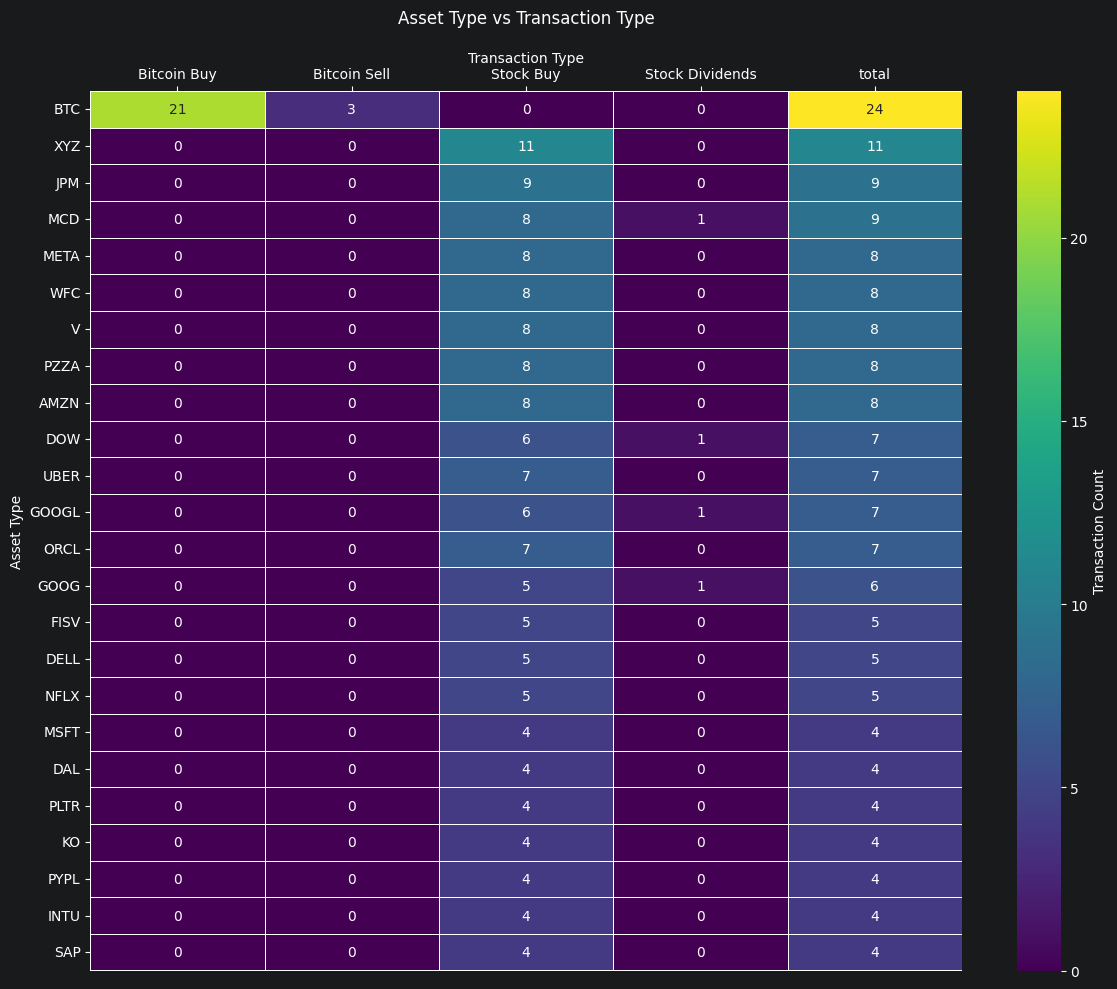

In [11]:
top_assets_heat = top_assets.drop(index='total', errors='ignore')

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    top_assets_heat,
    annot=True,
    fmt='g',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Transaction Count'},
    ax=ax,

)

ax.set_title('Asset Type vs Transaction Type', pad=20)
ax.set_ylabel('Asset Type', rotation=90)
ax.set_xlabel('Transaction Type', rotation=0)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()


In [12]:
data_btc = data[data['asset_type'] == 'BTC']
data_btc

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
41,2026-06-16 12:39:28+00:00,4.9,5.00,66069.72,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007568,NaN
42,2026-06-16 12:03:53+00:00,4.9,5.00,65883.50,0.000076,-0.10,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00007589,NaN
45,2026-06-16 01:27:11+00:00,-5.0,-4.90,66797.17,0.000073,-0.10,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00007336,NaN
81,2026-06-08 16:36:43+00:00,19.6,20.00,63160.58,0.000317,-0.40,BTC,Bitcoin Sell,USD,NaN,Cash Balance,COMPLETE,sale of BTC 0.00031665,NaN
161,2026-06-03 19:29:17+00:00,-10.0,-9.80,66010.01,0.000148,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014846,NaN
188,2026-06-03 16:16:50+00:00,-10.0,-9.80,66582.56,0.000147,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014719,NaN
212,2026-06-03 15:14:44+00:00,-1.0,-0.98,66904.02,0.000015,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001465,NaN
309,2026-06-03 13:08:30+00:00,-10.0,-9.80,67420.34,0.000145,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00014536,NaN
320,2026-06-02 19:54:00+00:00,-1.0,-0.98,67817.91,0.000014,-0.02,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00001445,NaN
337,2026-06-01 14:38:57+00:00,-10.0,-9.80,71929.33,0.000136,-0.20,BTC,Bitcoin Buy,USD,NaN,Cash Balance,COMPLETE,purchase of BTC 0.00013624,NaN


<Axes: xlabel='date'>

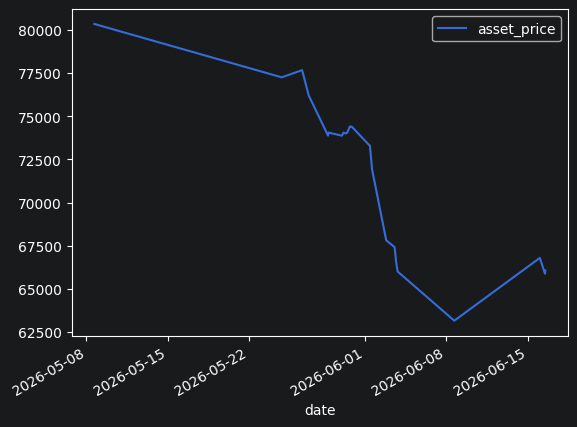

In [13]:
data_btc.plot.line(x='date', y='asset_price')

In [14]:
data_btc['trans_type'].value_counts()

trans_type
Bitcoin Buy     21
Bitcoin Sell     3
Name: count, dtype: int64

In [15]:
data_btc.pivot_table(index='trans_type', aggfunc='sum', values='net_amount')

,net_amount
trans_type,
Bitcoin Buy,-232.0
Bitcoin Sell,29.4


In [16]:
data_btc['net_amount'].sum()

np.float64(-202.6)

In [17]:
trans_btc = data_btc.pivot_table(index='trans_type', aggfunc='sum', values='asset_amount')['asset_amount']
trans_btc

trans_type
Bitcoin Buy     0.003100
Bitcoin Sell    0.000468
Name: asset_amount, dtype: float64

In [18]:
data_btc['asset_amount'].sum()

np.float64(0.0035680600000000005)

In [19]:
btc_amount = trans_btc['Bitcoin Buy'] - trans_btc['Bitcoin Sell']
btc_amount

np.float64(0.00263162)

Text(0, 0.5, 'BTC Price')

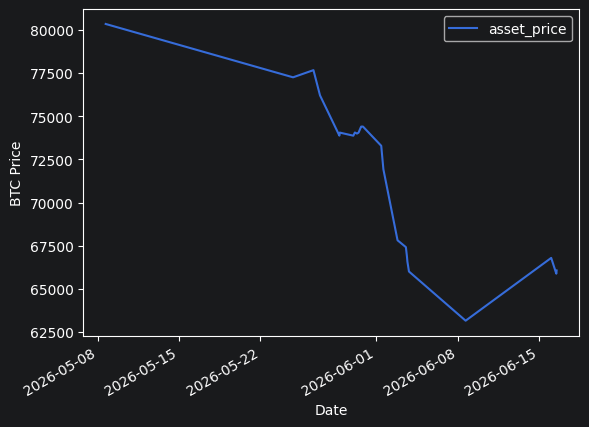

In [20]:
data_btc.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('BTC Price')

Text(0, 0.5, 'Holdings BTC')

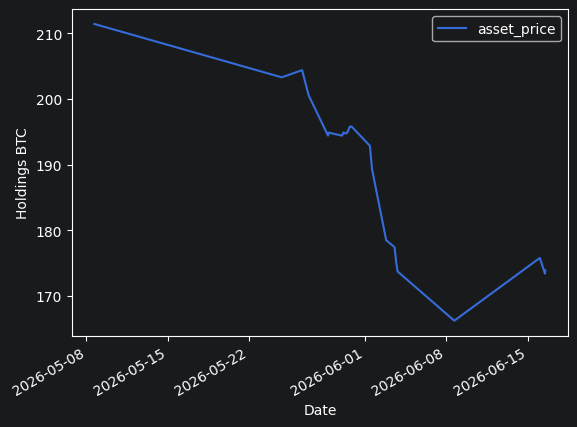

In [21]:
data_btc.assign(asset_price=lambda x: btc_amount * x['asset_price']).plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Holdings BTC')

In [22]:
data_btc['asset_price'] * data_btc['asset_amount']

41      5.000156
42      4.999899
45      4.900240
81     19.999798
161     9.799846
188     9.800287
212     0.980144
309     9.800221
320     0.979969
337     9.799652
395     4.900136
397     9.799865
400     4.900112
401     9.799903
405     9.799965
409    24.500200
416    24.499951
420    24.500084
439     9.799731
443     9.800031
466    24.499991
483     9.799898
484     4.900356
485     9.799819
dtype: float64

In [23]:
data_xyz = data[data['asset_type'] == 'XYZ']
data_xyz

,date,net_amount,amount,asset_price,asset_amount,fee,asset_type,trans_type,currency,trans_id,account,status,notes,name_trans
3,2026-06-16 13:31:47+00:00,-5.0,-5.0,74.95,0.06671,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$5 Purchase of Block,NaN
48,2026-06-15 13:32:07+00:00,-10.0,-10.0,72.26,0.13838,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
96,2026-06-04 13:31:36+00:00,-20.0,-20.0,70.84,0.28232,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$20 Purchase of Block,NaN
172,2026-06-03 19:22:37+00:00,-10.0,-10.0,69.87,0.14312,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
184,2026-06-03 16:57:03+00:00,-10.0,-10.0,69.67,0.14353,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
197,2026-06-03 15:50:14+00:00,-10.0,-10.0,69.62,0.14364,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
235,2026-06-03 13:43:52+00:00,-10.0,-10.0,71.59,0.13968,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$10 Purchase of Block,NaN
238,2026-06-03 13:33:56+00:00,-1.0,-1.0,72.82,0.01373,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$1 Purchase of Block,NaN
341,2026-06-01 13:30:51+00:00,-25.0,-25.0,77.50,0.32258,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$25 Purchase of Block,NaN
426,2026-05-29 13:33:18+00:00,-50.0,-50.0,75.00,0.66666,0.0,XYZ,Stock Buy,USD,NaN,Cash Balance,COMPLETE,$50 Purchase of Block,NaN


Text(0, 0.5, 'Price Block:XYZ')

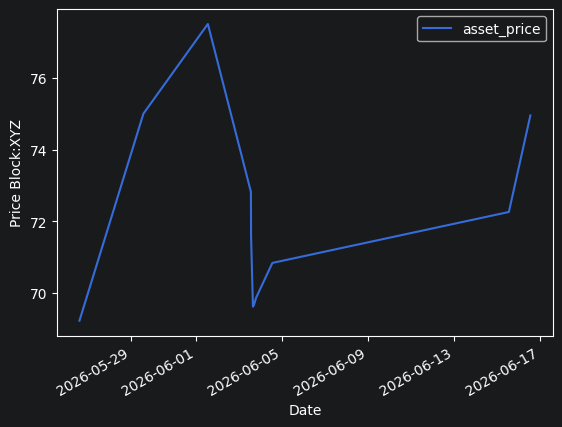

In [24]:
data_xyz.plot.line(x='date', y='asset_price')
plt.xlabel('Date')
plt.ylabel('Price Block:XYZ')

In [25]:
asset_count = data.groupby('asset_type')['amount'].count().sort_values(ascending=False)
asset_count

asset_type
BTC     24
XYZ     11
JPM     10
MCD      9
META     8
        ..
HIMS     1
HD       1
H        1
GSLC     1
ZG       1
Name: amount, Length: 163, dtype: int64

In [26]:
asset_price_time = (
    data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    .dropna(how='all')
)
asset_price_time

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 19:57:02+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-26 14:06:39+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-26 14:09:07+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,69.23,NaN,NaN,NaN,NaN
2026-05-27 03:38:54+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-16 13:31:37+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 13:31:47+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,74.95,NaN,NaN,NaN,NaN
2026-06-16 13:32:08+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
asset_price_rel = asset_price_time.div(asset_price_time.bfill().iloc[0]).ffill().fillna(1)
asset_price_rel

asset_type,AAPL,ABNB,ACN,ADBE,ADP,AFRM,ALKT,ALLY,AMAT,AMD,...,WDAY,WFC,WMG,WMT,XLB,XYZ,YUM,YUMC,Z,ZG
date,,,,,,,,,,,,,,,,,,,,,
2026-05-08 16:42:34+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
2026-05-24 19:57:02+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
2026-05-26 14:06:39+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
2026-05-26 14:09:07+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
2026-05-27 03:38:54+00:00,1.000000,1.0,1.000000,1.0,1.00,1.0,1.000000,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-16 13:31:37+00:00,1.018386,1.0,0.901125,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.043767,0.997325,1.0,1.0,1.0
2026-06-16 13:31:47+00:00,1.018386,1.0,0.901125,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.082623,0.997325,1.0,1.0,1.0
2026-06-16 13:32:08+00:00,1.018386,1.0,0.901125,1.0,1.01,1.0,0.954965,1.0,1.0,1.0,...,0.970726,1.035138,0.968648,0.976969,1.0,1.082623,0.997325,1.0,1.0,1.0


Text(0, 0.5, 'Relative Value of Asset Price')

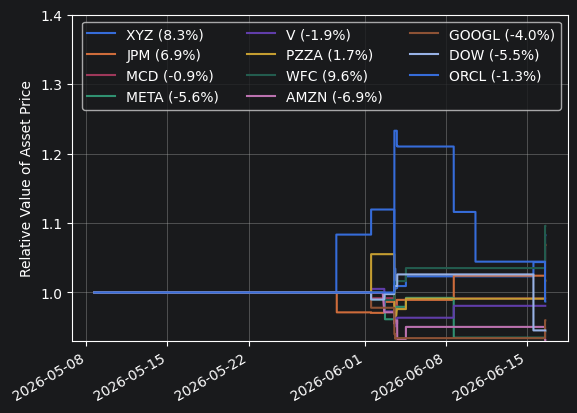

In [28]:
asset_price_rel_plot = asset_price_rel[asset_count.head(12).iloc[1::].index].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')

In [29]:
asset_price_rel['XYZ'].dropna()

date
2026-05-08 16:42:34+00:00    1.000000
2026-05-24 19:57:02+00:00    1.000000
2026-05-26 14:06:39+00:00    1.000000
2026-05-26 14:09:07+00:00    1.000000
2026-05-27 03:38:54+00:00    1.000000
                               ...   
2026-06-16 13:31:37+00:00    1.043767
2026-06-16 13:31:47+00:00    1.082623
2026-06-16 13:32:08+00:00    1.082623
2026-06-16 13:32:28+00:00    1.082623
2026-06-16 14:00:16+00:00    1.082623
Name: XYZ, Length: 295, dtype: float64

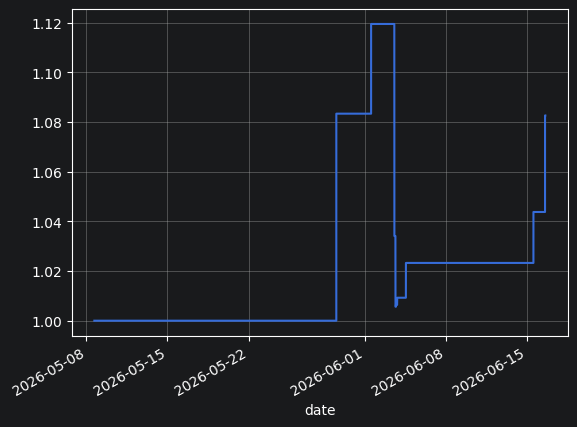

In [30]:
asset_price_rel['XYZ'].dropna().plot.line()
plt.grid()


In [31]:
(data[data['trans_type'] == 'Stock Dividends']
 .drop(columns=['asset_amount', 'fee', 'asset_price', 'trans_id', 'name_trans', 'account', 'currency', 'status'])
 )

,date,net_amount,amount,asset_type,trans_type,notes
43,2026-06-16 04:00:00+00:00,0.20,0.20,MCD,Stock Dividends,$0.20 Dividend from McDonald's
61,2026-06-15 04:00:00+00:00,0.02,0.02,GOOG,Stock Dividends,$0.02 Dividend from Alphabet Inc. Class C
62,2026-06-15 04:00:00+00:00,0.02,0.02,GOOGL,Stock Dividends,$0.02 Dividend from Alphabet Inc. Class A
65,2026-06-12 04:00:00+00:00,0.05,0.05,DOW,Stock Dividends,$0.05 Dividend from Dow
318,2026-06-03 04:00:00+00:00,0.03,0.03,VMBS,Stock Dividends,$0.03 Dividend from Vanguard Mortgage-Backed S...


In [32]:
vanguard_data = (data[data['notes'].str.lower().str.contains('vanguard')]
[['date', 'net_amount', 'asset_price', 'notes', 'asset_type']]
)
vanguard_data


,date,net_amount,asset_price,notes,asset_type
0,2026-06-16 14:00:16+00:00,-10.00,693.44,$10 Purchase of Vanguard S&P 500 ETF,VOO
17,2026-06-16 13:30:12+00:00,-5.00,107.50,$5 Purchase of Vanguard Russell 1000 Value ETF,VONV
31,2026-06-16 13:30:05+00:00,-5.00,132.21,$5 Purchase of Vanguard Financials ETF,VFH
32,2026-06-16 13:30:05+00:00,-5.00,98.42,$5 Purchase of Vanguard Real Estate ETF,VNQ
33,2026-06-16 13:30:03+00:00,-5.00,155.47,$5 Purchase of Energy ETF Vanguard,VDE
50,2026-06-15 13:30:28+00:00,-10.00,127.25,$10 Purchase of Vanguard Russell 1000 Growth ETF,VONG
51,2026-06-15 13:30:28+00:00,-10.00,107.49,$10 Purchase of Vanguard Russell 1000 Value ETF,VONV
57,2026-06-15 13:30:12+00:00,-10.00,231.00,$10 Purchase of Vanguard Consumer Staples Inde...,VDC
135,2026-06-03 19:46:16+00:00,-10.00,275.16,$10 Purchase of Vanguard Health Care ETF,VHT
151,2026-06-03 19:35:58+00:00,-10.00,158.69,$10 Purchase of Vanguard FTSE All World ex US ...,VSS


In [33]:
vanguard_trans_count = vanguard_data['asset_type'].value_counts()
vanguard_trans_count

asset_type
VONV    4
VFH     4
VMBS    4
VDE     3
VHT     3
VSS     3
VOO     2
VNQ     2
VDC     2
BNDX    2
VCR     2
VONG    1
VGLT    1
BIV     1
VTEB    1
VBR     1
Name: count, dtype: int64

In [34]:
vanguard_note_name = (
    vanguard_data['notes'].pipe(lambda x: x[x.str.contains('Purchase')])
    .str.replace('.*Purchase of', '', regex=True)
)
vanguard_data_asset_names = (vanguard_data.assign(name=vanguard_note_name)
                             .drop(columns=['notes'])
                             )
vanguard_data_asset_names

,date,net_amount,asset_price,asset_type,name
0,2026-06-16 14:00:16+00:00,-10.00,693.44,VOO,Vanguard S&P 500 ETF
17,2026-06-16 13:30:12+00:00,-5.00,107.50,VONV,Vanguard Russell 1000 Value ETF
31,2026-06-16 13:30:05+00:00,-5.00,132.21,VFH,Vanguard Financials ETF
32,2026-06-16 13:30:05+00:00,-5.00,98.42,VNQ,Vanguard Real Estate ETF
33,2026-06-16 13:30:03+00:00,-5.00,155.47,VDE,Energy ETF Vanguard
50,2026-06-15 13:30:28+00:00,-10.00,127.25,VONG,Vanguard Russell 1000 Growth ETF
51,2026-06-15 13:30:28+00:00,-10.00,107.49,VONV,Vanguard Russell 1000 Value ETF
57,2026-06-15 13:30:12+00:00,-10.00,231.00,VDC,Vanguard Consumer Staples Index Fund ETF
135,2026-06-03 19:46:16+00:00,-10.00,275.16,VHT,Vanguard Health Care ETF
151,2026-06-03 19:35:58+00:00,-10.00,158.69,VSS,Vanguard FTSE All World ex US Small Cap ETF


In [35]:
vanguard_data_asset_names_trans_count = vanguard_data_asset_names.groupby(['asset_type', 'name'])[
    'date'].count().sort_values(ascending=False)
vanguard_data_asset_names_trans_count

asset_type  name                                       
VFH         Vanguard Financials ETF                        4
VONV        Vanguard Russell 1000 Value ETF                4
VDE         Energy ETF Vanguard                            3
VHT         Vanguard Health Care ETF                       3
VMBS        Vanguard Mortgage-Backed Securities ETF        3
VSS         Vanguard FTSE All World ex US Small Cap ETF    3
BNDX        Vanguard Total International Bond ETF          2
VCR         Vanguard Consumer Discretionary ETF            2
VDC         Vanguard Consumer Staples Index Fund ETF       2
VNQ         Vanguard Real Estate ETF                       2
VOO         Vanguard S&P 500 ETF                           2
BIV         Vanguard Intermediate Term Bond ETF            1
VBR         Small Cap Value ETF Vanguard                   1
VGLT        Vanguard Long-Treasury ETF                     1
VONG        Vanguard Russell 1000 Growth ETF               1
VTEB        Vanguard Tax-Exem

In [36]:
vanguard_asset_price_time = asset_price_time = (
    vanguard_data
    .pivot_table(index='date', columns='asset_type', aggfunc='median', values='asset_price')
    [vanguard_trans_count.index]
    .dropna(how='all')
)
vanguard_asset_price_time

asset_type,VONV,VFH,VMBS,VDE,VHT,VSS,VOO,VNQ,VDC,BNDX,VCR,VONG,VGLT,BIV,VTEB,VBR
date,,,,,,,,,,,,,,,,
2026-05-29 14:26:46+00:00,NaN,NaN,46.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:01+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233.47
2026-06-01 13:30:04+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.12,NaN
2026-06-01 13:30:06+00:00,NaN,NaN,46.56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:10+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397.97,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:11+00:00,NaN,125.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:15+00:00,104.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:16+00:00,NaN,NaN,NaN,160.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 13:30:23+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
vanguard_trans_count

asset_type
VONV    4
VFH     4
VMBS    4
VDE     3
VHT     3
VSS     3
VOO     2
VNQ     2
VDC     2
BNDX    2
VCR     2
VONG    1
VGLT    1
BIV     1
VTEB    1
VBR     1
Name: count, dtype: int64

Text(0, 0.5, 'Relative Value of Asset Price')

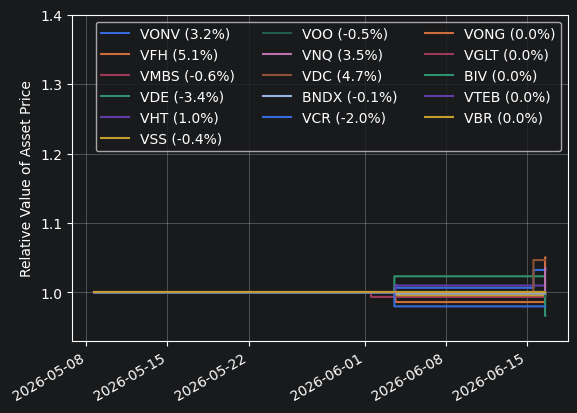

In [38]:
asset_price_rel_plot = asset_price_rel[list(vanguard_trans_count.index)].copy()
asset_price_rel_plot_perc = asset_price_rel_plot.iloc[-1].sub(1).mul(100).round(1)
asset_price_rel_plot.columns = [f'{col} ({perc}%)' for col, perc in
                                zip(asset_price_rel_plot.columns, asset_price_rel_plot_perc)]
asset_price_rel_plot.plot.line()
plt.grid()
plt.legend(ncols=3, loc='upper right')
plt.ylim(0.93, 1.4)
plt.xlabel('')
plt.ylabel('Relative Value of Asset Price')